# RBF - Cas d'images


In [55]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from rbf import lib, entrainer_rbf, predire_rbf, precision_rbf

from functions import load_dataset, melanger

project_root = os.path.abspath("..")
train_folder = os.path.join(project_root, "dataset", "train_dataset")
test_folder = os.path.join(project_root, "dataset", "test_dataset")

In [ ]:
# TEST avec 16*16*3

X_train_img, Y_train_img = load_dataset(train_folder, target_size=(16, 16), color=True)
X_test_img, Y_test_img = load_dataset(test_folder, target_size=(16, 16), color=True)
X_train_img, Y_train_img = melanger(X_train_img, Y_train_img, seed=42)

print(f"train={len(X_train_img)} test={len(X_test_img)}")


def courbe(x, err_train, err_test, xlabel, titre, log=False):
    plt.figure(figsize=(10, 5))
    plt.plot(x, err_train, label="train")
    plt.plot(x, err_test, label="test")
    if log:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("erreurs (%)")
    plt.legend()
    plt.title(titre)
    plt.show()

def courbe_train_test(x, accs_train, accs_test, xlabel, titre, log=False):
    plt.figure(figsize=(10, 5))
    plt.plot(x, accs_train, label="train")
    plt.plot(x, accs_test, label="test")
    if log:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("precision (%)")
    plt.legend()
    plt.title(titre)
    plt.show()

train=2400 test=600


### 5.1 Effet de gamma

K fixe a 100. Meme logique que le cercle : gamma trop petit -> bosses trop
larges -> sous-apprentissage ; gamma trop grand -> bosses trop etroites ->
sur-apprentissage.

gamma=1e-05 | train=55.29% test=51.67%
gamma=0.0001 | train=56.54% test=52.33%
gamma=0.001 | train=57.54% test=55.67%
gamma=0.01 | train=58.38% test=55.83%
gamma=0.1 | train=54.79% test=52.33%
gamma=1.0 | train=43.46% test=41.67%


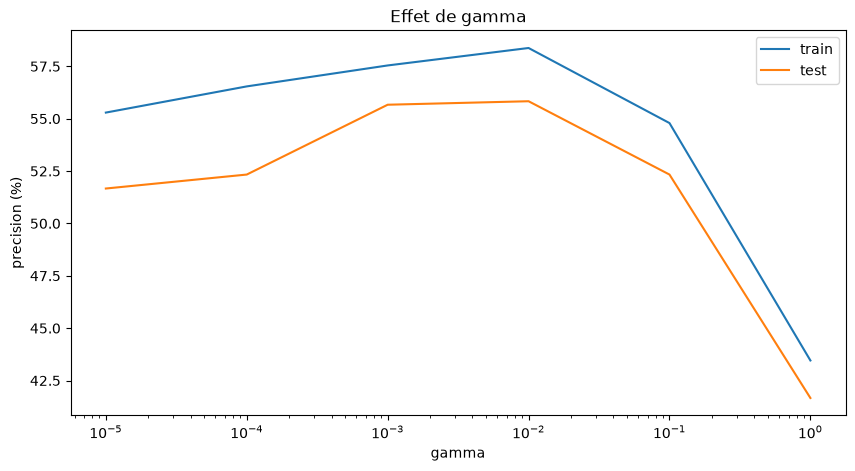

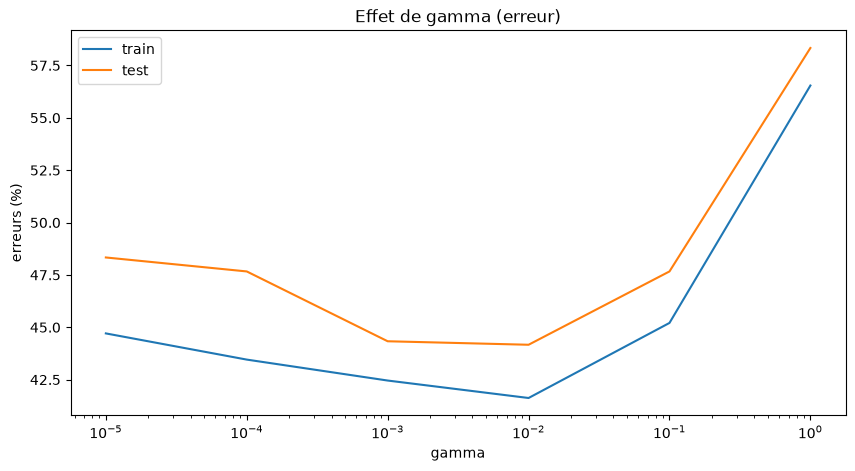

Meilleur gamma: 0.01


In [54]:
K_EXPLO = 100
gammas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]

accs_train, accs_test = [], []
for gamma in gammas:
    model = entrainer_rbf(X_train_img, Y_train_img, n_centres=K_EXPLO, gamma=gamma)
    accs_train.append(precision_rbf(model, X_train_img, Y_train_img))
    accs_test.append(precision_rbf(model, X_test_img, Y_test_img))
    lib.destroy_rbf_model(model)
    print(f"gamma={gamma} | train={accs_train[-1]:.2f}% test={accs_test[-1]:.2f}%")

courbe_train_test(gammas, accs_train, accs_test, "gamma", "Effet de gamma", log=True)
courbe(gammas, [100 - b for b in accs_train],[100 - a for a in accs_test], "gamma", "Effet de gamma (erreur)", log=True)

meilleur_gamma = gammas[int(np.argmax(accs_test))]
print(f"Meilleur gamma: {meilleur_gamma}")

### 5.2 Effet du nombre de centres K

Avec le meilleur gamma. Plus de centres = plus de capacite : trop peu ->
sous-apprentissage, trop -> sur-apprentissage (et entrainement plus lent).

In [33]:

accs_train, accs_test = [], []
for K in range(1, 200):
    model = entrainer_rbf(X_train_img, Y_train_img, n_centres=K, gamma=meilleur_gamma)
    accs_train.append(precision_rbf(model, X_train_img, Y_train_img))
    accs_test.append(precision_rbf(model, X_test_img, Y_test_img))
    lib.destroy_rbf_model(model)
    print(f"K={K} | train={accs_train[-1]:.2f}% test={accs_test[-1]:.2f}%")


K=1 | train=33.33% test=33.33%
K=2 | train=35.42% test=35.17%
K=3 | train=37.71% test=36.67%
K=4 | train=42.96% test=43.67%
K=5 | train=42.96% test=42.17%
K=6 | train=44.50% test=41.33%
K=7 | train=46.88% test=45.67%
K=8 | train=46.33% test=45.50%
K=9 | train=46.88% test=46.83%
K=10 | train=45.79% test=43.83%
K=11 | train=47.25% test=45.17%
K=12 | train=48.25% test=46.33%
K=13 | train=48.17% test=46.00%
K=14 | train=48.67% test=48.17%
K=15 | train=48.96% test=48.67%
K=16 | train=50.96% test=47.50%
K=17 | train=50.08% test=48.67%
K=18 | train=51.58% test=49.83%
K=19 | train=52.83% test=51.50%
K=20 | train=51.62% test=50.33%
K=21 | train=52.88% test=52.00%
K=22 | train=52.46% test=51.17%
K=23 | train=52.67% test=50.67%
K=24 | train=52.50% test=51.83%
K=25 | train=53.33% test=53.00%
K=26 | train=53.58% test=52.17%
K=27 | train=54.46% test=54.67%
K=28 | train=54.37% test=53.67%
K=29 | train=54.75% test=53.83%
K=30 | train=54.42% test=54.17%
K=31 | train=54.08% test=52.67%
K=32 | train=54.5

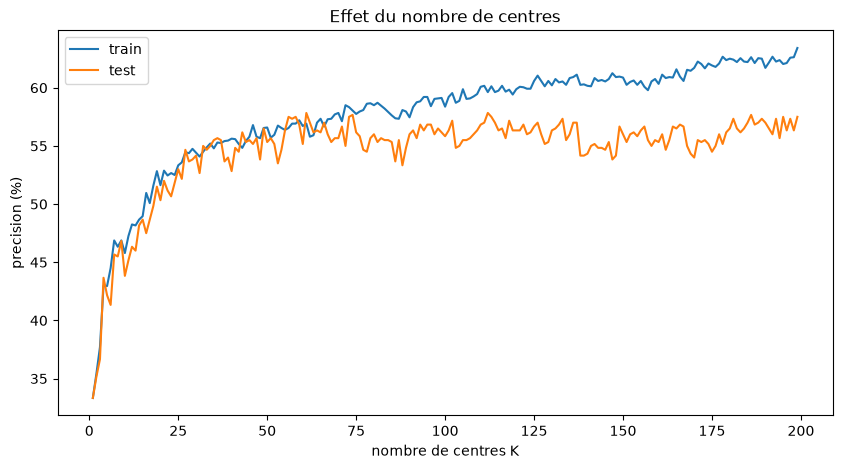

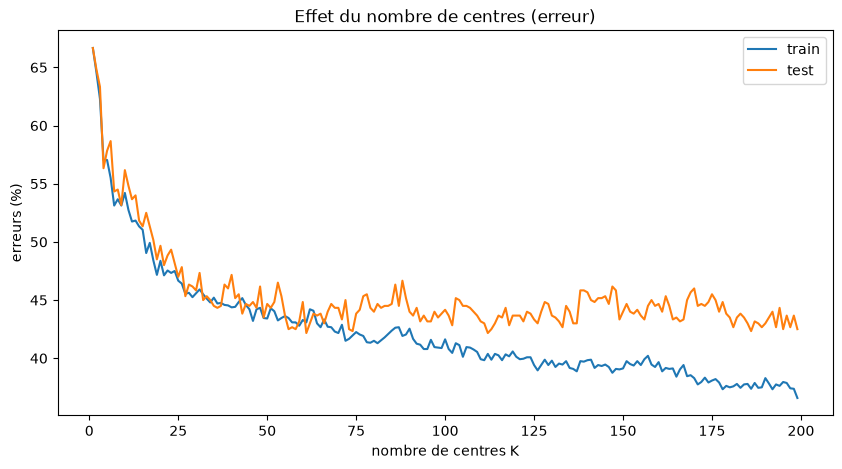

BEST: K= 61 | Accuracy test= 57.83% | Accuracy train= 56.92%


In [51]:
courbe_train_test([k for k in range(1, 200)], accs_train, accs_test, "nombre de centres K", "Effet du nombre de centres")
courbe([k for k in range(1, 200)], [100 - a for a in accs_train], [100 - a for a in accs_test], "nombre de centres K", "Effet du nombre de centres (erreur)")

#top 5
indice_max = int(np.argmax(accs_test))
meilleur_K = indice_max +1
print(f"BEST: K= {meilleur_K} | Accuracy test={accs_test[indice_max]: .2f}% | Accuracy train= {accs_train[indice_max]:.2f}%")

### 5.3 Modele final

Entrainement avec le gamma et le K retenus, matrice de confusion, puis
sauvegarde et verification par rechargement.

train=56.92%  test=57.83%


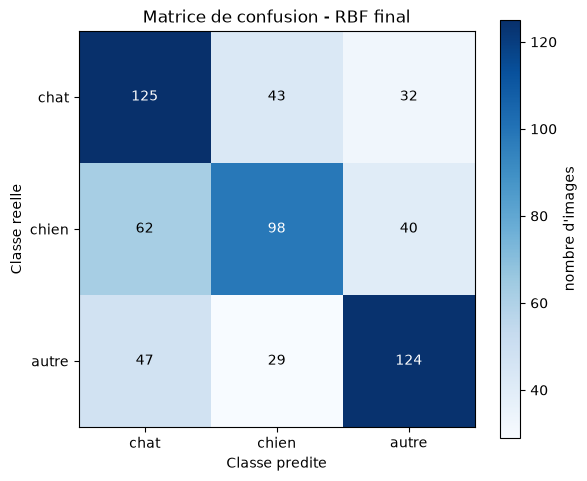

In [52]:
model_final = entrainer_rbf(X_train_img, Y_train_img, n_centres=meilleur_K, gamma=meilleur_gamma)
print(f"train={precision_rbf(model_final, X_train_img, Y_train_img):.2f}%  "
      f"test={precision_rbf(model_final, X_test_img, Y_test_img):.2f}%")

noms_classes = ["chat", "chien", "autre"]

def matrice_confusion(model, X, Y, nb_classes=3):
    matrice = np.zeros((nb_classes, nb_classes), dtype=int)
    for x, y_vrai in zip(X, Y):
        y_pred = predire_rbf(model, x)
        matrice[y_vrai][y_pred] += 1
    return matrice

cm = matrice_confusion(model_final, X_test_img, Y_test_img)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(noms_classes)))
ax.set_yticks(range(len(noms_classes)))
ax.set_xticklabels(noms_classes)
ax.set_yticklabels(noms_classes)
ax.set_xlabel("Classe predite")
ax.set_ylabel("Classe reelle")
ax.set_title("Matrice de confusion - RBF final")

seuil = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        couleur_texte = "white" if cm[i, j] > seuil else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=couleur_texte)

fig.colorbar(im, ax=ax, label="nombre d'images")
plt.tight_layout()
plt.show()

In [53]:
chemin = os.path.join(project_root, "models", "rbf.txt")
lib.save_rbf_model(model_final, chemin.encode())
lib.destroy_rbf_model(model_final)

model_charge = lib.load_rbf_model(chemin.encode())
print(f"test_acc (modele recharge) = {precision_rbf(model_charge, X_test_img, Y_test_img):.2f}%")
lib.destroy_rbf_model(model_charge)

test_acc (modele recharge) = 57.83%


### 5.4 Effet des resolution (16, 24, 32) 

- Gamma est une échelle de distance -> la résolution change les distances -> gamma doit être re-réglé à chaque résolution.
- K est un nombre de prototypes -> il dépend de la diversité du dataset (qui ne change pas quand on redimensionne les images) -> on peut le garder fixe.

In [56]:
# Chargement dataset
configs = {}
for resolution in (16, 24, 32):
    for couleur in (False, True):
        X_train, Y_train = load_dataset(train_folder, target_size=(resolution, resolution), color=couleur)
        X_test, Y_test = load_dataset(test_folder, target_size=(resolution, resolution), color=couleur)
        X_train, Y_train= melanger(X_train, Y_train, seed=42)

        configs[(resolution, couleur)] = (X_train, Y_train, X_test, Y_test)

for cle, (X_train, Y_train, X_test, Y_test) in configs.items():
    print(f"{cle}: train={len(X_train)}, test={len(X_test)}")


(16, False): train=2400, test=600
(16, True): train=2400, test=600
(24, False): train=2400, test=600
(24, True): train=2400, test=600
(32, False): train=2400, test=600
(32, True): train=2400, test=600


In [57]:
K_FIXE = meilleur_K
gammas_grille = [0.00001, 0.0001, 0.001, 0.01, 0.1]

resultats = {}
for cle, (X_train, Y_train, X_test, Y_test) in configs.items():
    best = (None, 0.0, 0.0)  # (gamma, acc_train, acc_test)
    for gamma in gammas_grille:
        model = entrainer_rbf(X_train, Y_train, n_centres=K_FIXE, gamma=gamma)
        acc_tr = precision_rbf(model, X_train, Y_train)
        acc_te = precision_rbf(model, X_test, Y_test)
        lib.destroy_rbf_model(model)
        if acc_te > best[2]:
            best = (gamma, acc_tr, acc_te)
    resultats[cle] = best
    print(f"{cle}: meilleur gamma={best[0]} | train={best[1]:.2f}% test={best[2]:.2f}%")


(16, False): meilleur gamma=0.1 | train=50.54% test=50.17%
(16, True): meilleur gamma=0.01 | train=56.92% test=57.83%
(24, False): meilleur gamma=0.01 | train=50.38% test=45.83%
(24, True): meilleur gamma=0.01 | train=56.71% test=57.00%
(32, False): meilleur gamma=0.01 | train=50.17% test=46.83%
(32, True): meilleur gamma=0.001 | train=56.83% test=55.83%


## 6. Conclusion

**Meilleur resultat : ~57.8 % de precision test, config 16x16 couleur**

Ce que les experiences montrent :

- **Effet de gamma** : comportement classique sous/sur-apprentissage.
  Gamma trop petit -> bosses trop larges, le modele ne separe rien ;
  gamma trop grand -> bosses trop etroites, le modele colle au train et
  generalise mal. Le meilleur gamma est entre les deux.

- **Effet de K** : la precision test monte vite jusqu'a K ~ 50-60 puis
  stagne autour de 55-58 %, alors que le train continue de monter :
  ajouter des centres augmente la capacite mais n'apporte plus
  d'information utile pour generaliser.

- **Couleur** : gain net (~+7 points par rapport au gris, a toutes les
  resolutions). La couleur porte de l'information discriminante pour
  chat / chien / autre.

- **Resolution** : aucun gain de 16 a 32. Plus de pixels = plus de
  dimensions, et les distances euclidiennes deviennent moins
  discriminantes (malediction de la dimension). On observe aussi que le
  gamma optimal diminue quand la resolution augmente, ce qui confirme
  que gamma depend de l'echelle des distances (donc de la dimension
  d'entree).
